# W3 — generalising state cells and coherent remapping, by brain regionDo neurons keep their task-state preference across tasks (**generalise**), or do they**remap** — and if they remap, do they remap **together**, and does "together" follow theanatomy?The recorded "LEC" bank spans ENTl-sup/deep, ENTm, SUB/ProS and CA1/HPF. No remappingresult in this repo has ever read that, and the question this notebook exists to answer iswhether coherently-remapping pairs are **same-region** (anatomically-defined modulesrotating independently) or **cross-region**.Plan: `docs/handoff/W3_remapping.md`. Machinery: [`w3_remapping.py`](w3_remapping.py),[`w3_figures.py`](w3_figures.py), [`anatomy_split.py`](anatomy_split.py). Controls:[`w3_synthetics.py`](w3_synthetics.py).## Three things to hold while reading**0. Coherence is a TWO-comparison criterion, so its chance level is 1/16.** A pair countsas coherent only if its relative rotation survives X→Y *and* X→Z (El-Gaby's dual criterion).One comparison landing within 45° is a one-in-four coin flip given point 1 below — far tooeasy to satisfy by accident to support a claim about rigid rotation — so the criterion issquared. `wf.dual_rate` is the headline; `wf.per_comparison_rate` (chance ¼) is kept for thesingle-neuron figures and as a diagnostic.**1. The estimator is a 4-way vote, not a continuous angle.** The task-phase spectrum isdominated by harmonic 4 (`TASKPHASE_PERIODICITY.md`: power fraction .098 against .057 ath=1, the largest harmonic in 84% of sessions), so the cross-correlation has four near-equalpeaks and its argmax is a state-identity vote with a noise tie-break. Chance is therefore**1/4**, and the null has to *preserve* h=4 — which a uniform circle does not. That null isthe **cell-identity shuffle**: neuron *i* in task X against neuron *j* in task Y, samecurves, correspondence broken. §2.4 measures the quantisation directly.**2. Every angle panel is read between two bands.** The **ceiling** is X-vs-X′, the samephysical task run twice — whatever it returns is measurement noise, not remapping. The**floor** is the cell-identity shuffle. A distribution sitting on the floor is a null resultand is reported as one. Each recday is also tested against **its own** shuffle, which isstronger than a test against a single analytic constant: every recday has its own rates,trial counts and task count, so its floor sits in a slightly different place.**3. Aggregation: the recday is the atom, and both levels are reported.** A statistic iscomputed **per recday first**, then averaged within a mouse. Pooling a mouse's rows andtaking one rate would be pair-weighted — and `n_pairs ~ n²`, so a recday with twice theneurons carries four times the weight and the mouse's number becomes its best-yield day.Every summary panel therefore shows **open circles = recdays (n≈25)** and **filled = mice(n=5)**, with a significance test against chance at *each* level. Recdays are a legitimatereplicate for a within-recday quantity like pair coherence; mice are the conservative unit,because the five recdays of a mouse are the same probe in the same brain, re-sorted. Wherethe two disagree, the mouse-level number is the one that carries the claim.ENTl-sup is 90% ah08 and ENTm is 63% ly07 — those are single-animal claims wearing a regionlabel.**4. X-vs-X′ gets its own dial, never an overlay.** It peaks so hard at 0 that overlaying itsets the radial limit and flattens the real distribution into the middle of the plot.## What it found| | ||---|---|| Gate (state-tuned in ≥ half of tasks) | **1755 / 2851 units**, 14.5–85.8% per recday || **Generalising state cells** | **12 in the whole cohort.** 0.257 vs chance ¼ — recday p=0.34, mouse p=0.31, only 14/23 recdays above their own shuffle. **A null**, against a ceiling of 0.81 || **Coherent remapping** (dual, chance 1/16) | 0.109 vs shuffle 0.063. **recday p=1e-9, mouse p=0.002, 24/25 recdays beat their own shuffle** || …not explained by co-tuned pairs | at 135–180° initial separation: 22/23 recdays beat their own shuffle, mouse p=0.001 || **Same-region vs cross-region** | gap +0.010; only **10/19 recdays positive**, mouse p=0.06, label-shuffle p=0.09, **and the largest mouse runs the other way** || Coherence modules vs anatomy | ARI 0.000 vs null 0.000, 1/25 recdays at p<0.05 |**Cells remap almost completely, they remap coherently, and the coherence is notanatomical.** Region does not organise it.

In [1]:
import os, sys, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('.'))
import anatomy_split as asplit
import w3_remapping as w3
import w3_figures as wf
import glm_analysis_v2 as glm

glm.apply_gridmaze_style()          # Arial 8pt, no top/right spines, Type-42
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 60)

FIG_DIR = w3.FIG_DIR                # data/figures/anatomy_split — png + pdf for every figure
os.makedirs(FIG_DIR, exist_ok=True)
print('figures ->', FIG_DIR)

figures -> /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split


## §0 — Load, join, and the guardsThe join onto region labels is **positional**: row *k* of `unit_regions[recday]` is row *k*of `Neuron_raw`. Nothing matches by name, so a result computed against a different unitcount would misalign every neuron after the first mismatch. `anatomy_split.join_regions`refuses to join unless the lengths agree — that assert is the whole safety net and it runsinside `neuron_frame`.Build the cache first if it does not exist:    python w3_remapping.py --synthetic     # blocking controls    python w3_remapping.py --run           # ~20 min, writes w3_remapping.pkl    python w3_remapping.py --extras        # split-half floors + CCGP (loads data_dic once)

In [2]:
results, meta = w3.load_cache()
unit_regions = asplit.load_unit_regions()
rates = w3.load_rates()                     # per-unit mean_rate_hz from w0_gates.pkl

neurons = w3.neuron_frame(results, unit_regions, rates)   # one row per unit
pairs = w3.pair_frame(results, unit_regions)              # one row per simultaneous pair
included = neurons[neurons['included']]

try:
    with open(os.path.join(w3.REPO, 'data', 'processed_data', 'w3_extras.pkl'), 'rb') as fh:
        extras = pickle.load(fh)
except FileNotFoundError:
    extras = {}
    print('w3_extras.pkl not found — run `python w3_remapping.py --extras` for §2.3 and §4')

print(f"{len(results)} recdays | {len(neurons)} units | {len(included)} gated "
      f"| {len(pairs):,} pairs | {neurons['mouse'].nunique()} mice")
print('tasks per recday:', sorted({len(r['unique_sessions']) for r in results.values()}))
print('comparisons per recday:', sorted(neurons.groupby('recday')['n_comparisons'].max().unique()))

25 recdays | 2851 units | 1465 gated | 59,731 pairs | 5 mice
tasks per recday: [4, 5, 6, 7]
comparisons per recday: [np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## §1 — Stage A: the gate, and what it makes feasibleThe gate is the El-Gaby peak-z t-test at parity (`identify_state_tuned_neurons`), includedif state-tuned in ≥ half of a recday's tasks. **It is rate-dependent and rate is confoundedwith region** (SUB/ProS 5.86 Hz vs ENTl-sup 1.07 Hz pooled, and *inverted* in ly06), so thepass rate is reported as the selection statistic it is, not as a clean regional property.Stage A is blocking because it decides whether Stage C exists: W3 projected that a 25% passrate collapses SUB/ProS to a single recday.

In [3]:
pass_rate = (included.groupby(['group', 'mouse']).size()
             / neurons.groupby(['group', 'mouse']).size()).unstack()
pass_rate = pass_rate.reindex(asplit.ANALYSIS_GROUPS)
print('Gate pass rate (%) — the mouse effect is larger than the region effect')
print((pass_rate * 100).round(1).to_string())
print('\nn units')
print(neurons.groupby(['group', 'mouse']).size().unstack().reindex(asplit.ANALYSIS_GROUPS).to_string())

counts, feas = asplit.feasibility_table(neurons, mask_col='included', min_units=10)
print('\nIncluded units per recday x region')
print(counts.to_string())
print('\nWhat survives at >=10 gated units per region per recday:')
print(feas.to_string(index=False))

Gate pass rate (%) — the mouse effect is larger than the region effect


mouse      ah08  ah10  ly05  ly06  ly07
group                                  
ENTl-sup   30.6  44.4  20.4  23.1   NaN
ENTl-deep  34.8  83.3  33.0  36.8  84.4
ENTm        NaN  63.6  58.8  40.8  52.5
SUB/ProS    NaN  85.8  45.7  33.6  66.0
CA1/HPF     NaN  78.8  38.2   NaN   NaN

n units
mouse       ah08   ah10   ly05   ly06   ly07
group                                       
ENTl-sup   611.0    9.0   49.0   13.0    NaN
ENTl-deep  181.0  378.0  182.0  133.0   90.0
ENTm         NaN   22.0   34.0   49.0  179.0
SUB/ProS     NaN  176.0   70.0  137.0  144.0
CA1/HPF      NaN  113.0  136.0    NaN    NaN
Feasibility at min_units=10 per region per recday (gate: included)

Included units per recday x region
group                  mouse  ENTl-sup  ENTl-deep  ENTm  SUB/ProS  CA1/HPF
recday                                                                    
ah08_20250613_20250615  ah08        22         14     0         0        0
ah08_20250616_20250617  ah08        32          6     0         0   

**Result.** The gate passes 1755/2851 unit-recordings, but the spread is driven by *mouse*,not region: ENTl-deep runs 33% in ly05 and 84% in ly07. Within a mouse the ordering isconsistent (ENTl-sup always lowest), which is what the rate confound predicts.**The primary contrast survives.** ENTl-deep vs SUB/ProS clears 10 gated units per region in**13 recdays across 4 mice** — better than W3's projection. Stage C exists.

## §2 — Stage B: do single neurons keep their state preference?### 2.1 Figure 1 — all gated neurons

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig1_all_neurons_xcorr.{png,pdf}
per recday:
                recday  n_rows  shuffle  real  ceiling
ah08_20250613_20250615      36    0.267 0.222    0.667
ah08_20250616_20250617      38    0.197 0.211    0.605
ah08_20250618_20250619      65    0.225 0.234    0.754
ah08_20250620_20250623      41    0.262 0.299      NaN
ah08_20250624_20250625      70    0.248 0.276      NaN
ah10_20250613_20250615     116    0.262 0.307    0.918
ah10_20250616_20250617     126    0.219 0.095    0.782
ah10_20250618_20250619     139    0.240 0.266    0.835
ah10_20250620_20250623     128    0.212 0.197    0.875
ah10_20250624_20250625     128    0.228 0.214      NaN
ly05_20250616_20250617      24    0.183 0.225    0.750
ly05_20250618_20250619      45    0.244 0.244    0.733
ly05_20250620_20250623      54    0.204 0.327      NaN
ly05_20250624_20250625      39    0.325 0.487      NaN
ly06_20250616_20250617      28    0.300 0.3

np.float64(-0.007886435331230283)

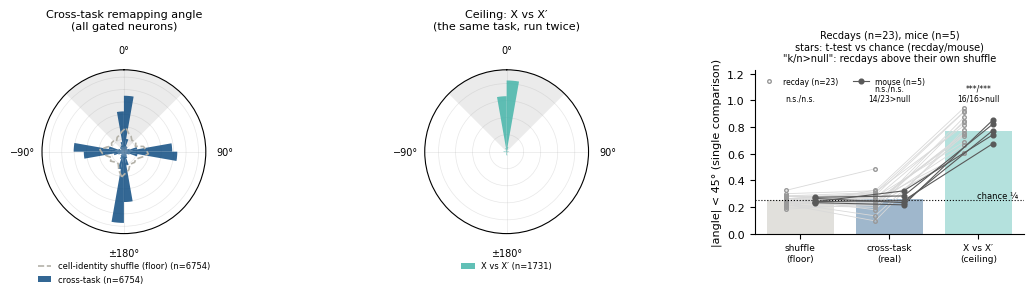

In [4]:
fig1, rd1, pm1 = wf.fig1_all_neurons(neurons, save_dir=FIG_DIR)
print('per recday:'); print(rd1[['recday', 'n_rows', 'shuffle', 'real', 'ceiling']].round(3).to_string(index=False))
print('\nper mouse:'); print(pm1[['mouse', 'n_recdays', 'shuffle', 'real', 'ceiling']].round(3).to_string(index=False))
print(f"\nvs chance {w3.CHANCE}:  recday {wf.test_vs_chance(rd1['real'], w3.CHANCE)}")
print(f"                 mouse  {wf.test_vs_chance(pm1['real'], w3.CHANCE)}")
print(f"paired vs each recday's OWN shuffle: {wf.test_vs_shuffle(rd1['real'], rd1['shuffle'])}")
print(f"\ngeneralising cells (|angle| < 45 deg in EVERY comparison): "
      f"{int(included['generalising_xcorr'].sum())} of {len(included)}")

# Task ordering is arbitrary, so the pooled histogram must be symmetric about 0.
# Asymmetry would mean the pipeline is comparing in a consistent direction somewhere.
w3.assert_symmetric(wf.stack(included, 'angles_xcorr'), 'figure 1')

**Result — a null at both levels.** The cross-task rate is **0.257** against a chance of0.25: recdays (n=23) p=0.34, mice (n=5) p=0.31, and only **14 of 23 recdays** sit abovetheir own shuffle (paired p=0.20) — a coin flip. Only **12 cells in the entire cohort** hold|angle| < 45° across every task comparison.This is not a failure of measurement. The X-vs-X′ ceiling is **0.814** — run the same tasktwice and the estimator recovers the same tuning 81% of the time. The estimator works; thereis simply no cross-task constancy of state preference to find.It is also the predicted direction. The production GLM ranks `task_state` last of 16 in LEC,and `CCGP_STATE_PAIRS.md` reports CCGP 0.426 against a 0.500 null. Three independent measuresnow agree that state *identity* does not generalise across tasks.

### 2.2 Figure 2 — by regionTwo things must be on this figure or it cannot be read. **Rate matching**, because powerscales with rate and rate is confounded with region. And each region's **own split-halfnoise floor**, because a low-rate region gives a noisier argmax, and a noisier argmax gives a*flatter* histogram — which reads as "more remapping" with no biology behind it.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig2_per_region_xcorr.{png,pdf}
Split-half (within-session) reliability floor per region — how much of any regional difference could be measurement noise:
              n  median_abs_deg  frac_within_45
group                                          
CA1/HPF     850             3.0            0.85
ENTl-deep  3761             3.0            0.86
ENTl-sup    845             9.0            0.67
ENTm        931             6.0            0.73
SUB/ProS   2216             3.0            0.87

Per-region, per-mouse cross-task rate (chance 0.25):


    group  n_mice  n_recdays  n_units  effect_pooled_over_mice        evidence  single_mouse_caveat
 ENTl-sup       4         15      204                 0.001471 primary-capable ah08 (611/682 units)
ENTl-deep       5         25      563                 0.010714 primary-capable                     
     ENTm       4         20      148                 0.010000 primary-capable ly07 (179/284 units)
 SUB/ProS       4         20      324                 0.016234 primary-capable                     
  CA1/HPF       2         10      141                 0.021429       secondary                     


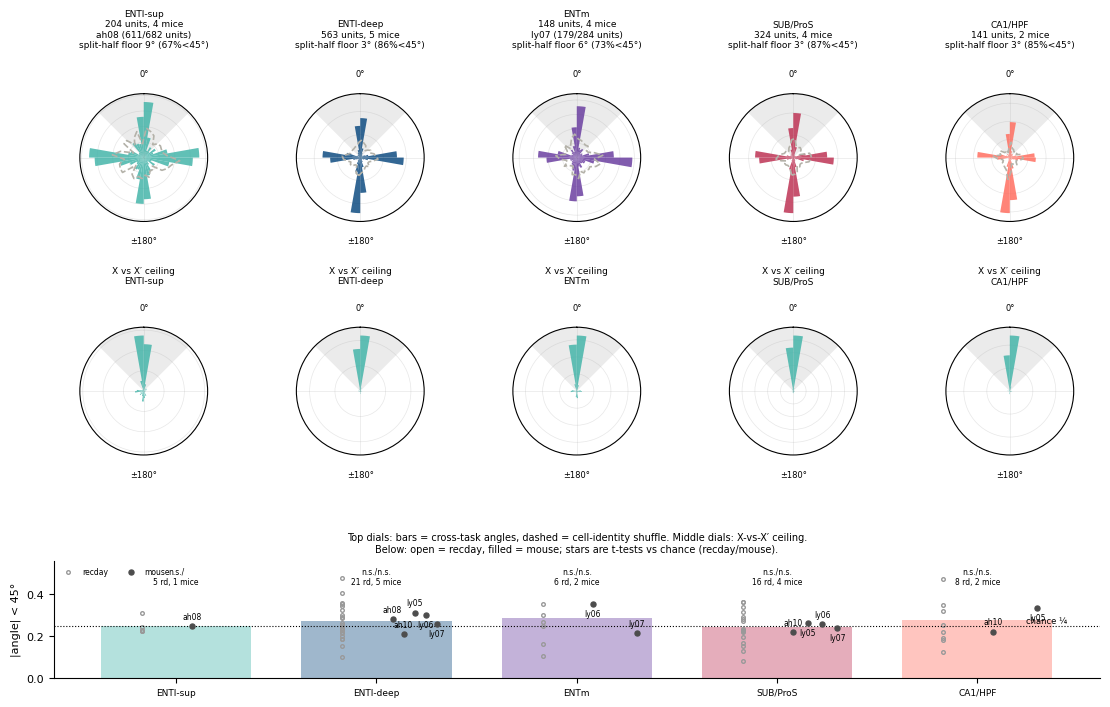

In [5]:
floors = extras.get('splithalf_floors')
fig2 = wf.fig2_per_region(neurons, floors=floors, save_dir=FIG_DIR)

if floors is not None:
    f = floors.assign(abs_deg=floors['angle_deg'].abs())
    print('Split-half (within-session) reliability floor per region — how much of any '
          'regional difference could be measurement noise:')
    print(f.groupby('group')['abs_deg']
          .agg(n='size', median_abs_deg='median',
               frac_within_45=lambda s: (s < w3.GEN_THRESHOLD_DEG).mean()).round(2).to_string())
    print()

print('Per-region, per-mouse cross-task rate (chance 0.25):')
rep = asplit.per_region_report(included, 'generalising_xcorr', statistic='mean')
print(rep[['group', 'n_mice', 'n_recdays', 'n_units', 'effect_pooled_over_mice',
           'evidence', 'single_mouse_caveat']].to_string(index=False))

In [6]:
# Robustness on the primary contrast: does anything change once rate is matched?
rm = asplit.rate_match(included, 'mean_rate_hz', *asplit.PRIMARY_CONTRAST)
print(f'rate-matched: {len(rm)} units, {rm["group"].value_counts().to_dict()}')
for g in asplit.PRIMARY_CONTRAST:
    print(f'  {g:>10}: all units {wf.per_comparison_rate(included[included.group == g], "angles_xcorr"):.3f}'
          f'   rate-matched {wf.per_comparison_rate(rm[rm.group == g], "angles_xcorr"):.3f}')

print('\nContrast with mice as the resampling unit:')
print(asplit.cluster_bootstrap(included, 'generalising_xcorr', *asplit.PRIMARY_CONTRAST))
print('\nWithin-recday permutation of the region labels:')
print(asplit.within_recday_permutation(included, 'generalising_xcorr',
                                       *asplit.PRIMARY_CONTRAST, n_perm=2000))

rate-matched: 390 units, {'ENTl-deep': 195, 'SUB/ProS': 195}
   ENTl-deep: all units 0.233   rate-matched 0.231
    SUB/ProS: all units 0.237   rate-matched 0.227

Contrast with mice as the resampling unit:


{'contrast': 'ENTl-deep - SUB/ProS', 'n_mice': 4, 'per_mouse_diff': {'ah10': 0.0, 'ly05': -0.0114, 'ly06': 0.0, 'ly07': 0.0}, 'mean_diff': -0.00284090909090909, 'ci_lo': -0.00852272727272727, 'ci_hi': 0.0, 'p_boot': 0.6336, 'usable_as': 'primary'}

Within-recday permutation of the region labels:


{'contrast': 'ENTl-deep - SUB/ProS', 'observed': -0.00284090909090909, 'null_mean': -0.00017343749999999903, 'null_sd': 0.011392855935513365, 'p_perm': 0.8940529735132434, 'n_perm': 2000}


**Result.** Every region sits at chance, and rate matching moves nothing (ENTl-deep0.233 → 0.231; SUB/ProS 0.237 → 0.227). The null is uniform across the bank — there is noregion in which state cells generalise.

### 2.3 Both angle metrics, and which letterThe two metrics disagree informatively: the correlation-maximising shift uses the wholecurve, the peak-bin difference uses only the mode, so divergence means broad or bimodaltuning. W3 also asks, over generalising cells, whether A/B/C/D are used unequally.

In [7]:
print(f"metric agreement (xcorr vs peak on the same cell): "
      f"{included['metrics_agree'].mean():.3f}")
for m in w3.METHODS:
    print(f"  {m:>6}: generalising {int(included['generalising_' + m].sum()):>3}, "
          f"per-comparison rate {wf.per_comparison_rate(included, 'angles_' + m):.3f}")

gen = included[included['generalising_xcorr']]
print(f"\nPreferred state of the {len(gen)} generalising cells, by region:")
print(gen.groupby('group')['pref_state_ref'].value_counts().unstack(fill_value=0).to_string())
print("\nLevel 3 ('which letter?') is NOT ANSWERABLE on this dataset: 12 generalising cells "
      "spread over 5 regions and 4 states. No chi-square on that table means anything, and "
      "the question is downstream of a generalising population that does not exist.")

metric agreement (xcorr vs peak on the same cell): 0.990
   xcorr: generalising  12, per-comparison rate 0.237
    peak: generalising   5, per-comparison rate 0.236

Preferred state of the 12 generalising cells, by region:
pref_state_ref  0.0  1.0  2.0  3.0
group                             
CA1/HPF           1    1    0    1
ENTl-deep         1    1    1    1
ENTl-sup          0    0    0    1
ENTm              0    0    0    1
SUB/ProS          0    2    0    1

Level 3 ('which letter?') is NOT ANSWERABLE on this dataset: 12 generalising cells spread over 5 regions and 4 states. No chi-square on that table means anything, and the question is downstream of a generalising population that does not exist.


### 2.4 The h=4 quantisation, measuredThe framing in the header claims the estimator is quantised onto multiples of 90°. That istestable: take each angle's distance to the nearest multiple of 90. Uniform would give amean of 22.5°.

In [8]:
resid = included.groupby('group')['mean_abs_resid90_xcorr'].mean()
print('Mean distance to the nearest multiple of 90 deg (22.5 = uniform):')
print(resid.round(2).to_string())
sh = w3.dist_to_multiple_of_90(wf.stack(included, 'angles_shuffle_xcorr'))
print(f"\nshuffle: {np.nanmean(sh):.2f} deg — the quantisation is a property of the CURVES, "
      f"not of any cross-task relationship, which is exactly why the shuffle is the right "
      f"null and a uniform circle is not.")

Mean distance to the nearest multiple of 90 deg (22.5 = uniform):
group
CA1/HPF        10.56
ENTl-deep      10.06
ENTl-sup       14.00
ENTm           13.34
SUB/ProS        9.03
fibre/other     6.98

shuffle: 20.06 deg — the quantisation is a property of the CURVES, not of any cross-task relationship, which is exactly why the shuffle is the right null and a uniform circle is not.


## §3 — Stage C: coherent remappingCells can remap completely and still remap **together**. This is the pairwise question, andit is the one that can be positive while §2 is null.### 3.1 Figure 3 — all pairs`rel` is the reference-anchored relative rotation r_j − r_i (El-Gaby). `direct` is thewithin-task pair angle Δ_ij(t) − Δ_ij(ref), which is algebraically the same where bothphases are well defined but does not let one neuron's bad rotation estimate corrupt everypair it appears in. They are plotted together: where they disagree, the reference task isthe suspect.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig3_all_pairs.{png,pdf}
per mouse (mean of that mouse's recdays):
mouse  n_recdays  shuffle   real  direct  ceiling
 ah08          5   0.0614 0.0865  0.0934      NaN
 ah10          5   0.0630 0.1313  0.1180   0.5576
 ly05          5   0.0587 0.1044  0.1204      NaN
 ly06          5   0.0697 0.1175  0.1274   0.4978
 ly07          5   0.0618 0.1056  0.1170   0.4239

DUAL chance = 0.0625; the shuffle lands at 0.0629 — the empirical null recovers the analytic chance level.
vs chance:  recday {'n': 25, 'mean': 0.10906411268812873, 'p': 9.680659609762013e-10, 'stars': '***'}
            mouse  {'n': 5, 'mean': 0.10906411268812873, 'p': 0.0016591720417564032, 'stars': '**'}
paired vs each recday's OWN shuffle: {'n': 25, 'mean_gap': 0.04616311950605109, 'n_positive': 24, 'p': 1.4901161193847656e-07, 'stars': '***'}

ref-anchored vs direct: max per-mouse difference 0.0160
all-comparison-pairs vs El-Gaby pari

np.float64(0.00792355593729869)

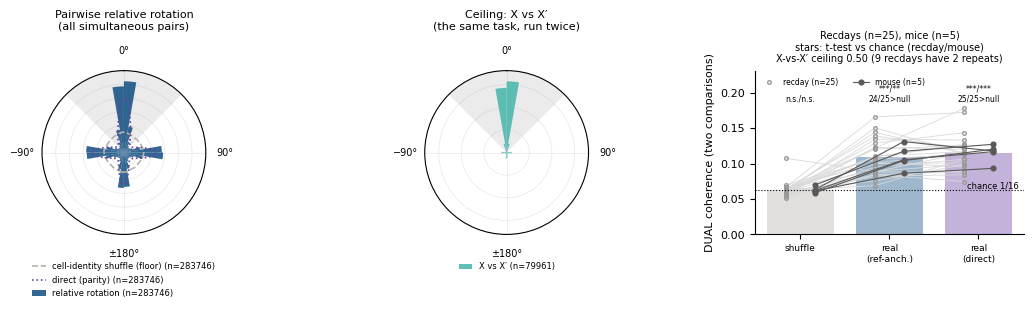

In [9]:
fig3, rd3, pm3 = wf.fig3_all_pairs(pairs, save_dir=FIG_DIR)
print('per mouse (mean of that mouse\'s recdays):')
print(pm3[['mouse', 'n_recdays', 'shuffle', 'real', 'direct', 'ceiling']].round(4).to_string(index=False))
print(f"\nDUAL chance = {wf.DUAL_CHANCE:.4f}; the shuffle lands at "
      f"{rd3['shuffle'].mean():.4f} — the empirical null recovers the analytic chance level.")
print(f"vs chance:  recday {wf.test_vs_chance(rd3['real'], wf.DUAL_CHANCE)}")
print(f"            mouse  {wf.test_vs_chance(pm3['real'], wf.DUAL_CHANCE)}")
print(f"paired vs each recday's OWN shuffle: {wf.test_vs_shuffle(rd3['real'], rd3['shuffle'])}")
print(f"\nref-anchored vs direct: max per-mouse difference "
      f"{(pm3['real'] - pm3['direct']).abs().max():.4f}")
print(f"all-comparison-pairs vs El-Gaby parity (first two only): max per-recday difference "
      f"{(rd3['real'] - rd3['real_parity']).abs().max():.4f}")
w3.assert_symmetric(wf.stack(pairs, 'rel'), 'figure 3')

**Result — positive at both levels.** Dual coherence is **0.109 against a shuffle of0.063** and a chance of 1/16 = 0.0625: **recdays (n=25) p = 1×10⁻⁹, mice (n=5) p = 0.002**,and **24 of 25 recdays beat their own shuffle** (paired p = 1×10⁻⁷). Every mouse is aboveits own floor (0.087–0.131 against 0.059–0.070).Three things make it trustworthy:- the **shuffle recovers the analytic chance level** (0.063 against 0.0625), so the 1/16  reasoning and the empirical null agree;- the **reference-anchored and direct metrics agree**, so it is not an artefact of the anchor;- averaging over all comparison-pairs and **El-Gaby's strict first-two parity** agree.So: **state identity remaps, but pairs of cells hold their relative task-space angle.**

### 3.2 The control that decides whether §3.1 is realA pair whose two cells already peak at the same task-space phase is close to triviallycoherent — and **two cells with the same place field would sit exactly there**, then movetogether across tasks for a reason that has nothing to do with the population rotating. Thecoherence claim only survives if it holds for pairs that started **far apart** on the ring,where no shared place field can produce it.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig6_coherence_by_initial_angle.{png,pdf}


     0-45deg: 24 recdays, real 0.1298 shuffle 0.0620 gap +0.0678, 24/24 recdays > own null | vs 1/16: recday *** (p=2.8e-10), mouse *** (p=0.001)
    45-90deg: 23 recdays, real 0.1070 shuffle 0.0630 gap +0.0440, 21/23 recdays > own null | vs 1/16: recday *** (p=4.6e-07), mouse ** (p=0.006)
   90-135deg: 24 recdays, real 0.0960 shuffle 0.0612 gap +0.0347, 22/24 recdays > own null | vs 1/16: recday *** (p=3.7e-07), mouse ** (p=0.006)
  135-180deg: 23 recdays, real 0.0960 shuffle 0.0579 gap +0.0382, 22/23 recdays > own null | vs 1/16: recday *** (p=1.3e-07), mouse ** (p=0.001)


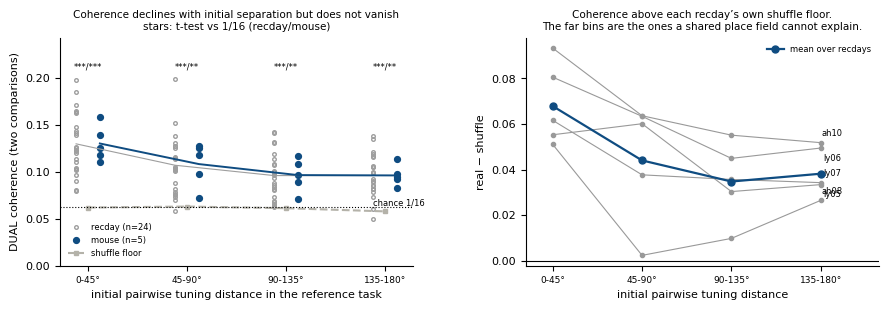

In [10]:
fig6, rd6 = wf.fig6_coherence_by_initial_angle(pairs, save_dir=FIG_DIR)
_, pm6 = wf.coherence_by_initial_angle_levels(pairs)
for b in sorted(rd6['bin'].unique()):
    s, sm = rd6[rd6['bin'] == b], pm6[pm6['bin'] == b]
    t_rd = wf.test_vs_chance(s['real'], wf.DUAL_CHANCE)
    t_ms = wf.test_vs_chance(sm['real'], wf.DUAL_CHANCE)
    ts = wf.test_vs_shuffle(s['real'], s['shuffle'])
    print(f"{s['label'].iloc[0]:>12}: {len(s):2d} recdays, real {s['real'].mean():.4f} "
          f"shuffle {s['shuffle'].mean():.4f} gap {ts['mean_gap']:+.4f}, "
          f"{ts['n_positive']}/{ts['n']} recdays > own null | vs 1/16: "
          f"recday {t_rd['stars']} (p={t_rd['p']:.1e}), mouse {t_ms['stars']} (p={t_ms['p']:.3f})")

**Result — the control passes.** Dual coherence declines with initial separation (0.130 at0–45° to 0.096 at 135–180°) but does not vanish. In the **far bin (135–180°)** it is still**+0.038 above the shuffle**, with **22 of 23 recdays above their own null**, recdayp = 1×10⁻⁷ and **mouse p = 0.001**. The coherence is not an artefact of similarly-tuned —or co-place-tuned — pairs.

### 3.2b The same control, per regionWithin-region pairs only. The far bins are the ones that carry the claim.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig6_by_initial_angle_per_region.{png,pdf}


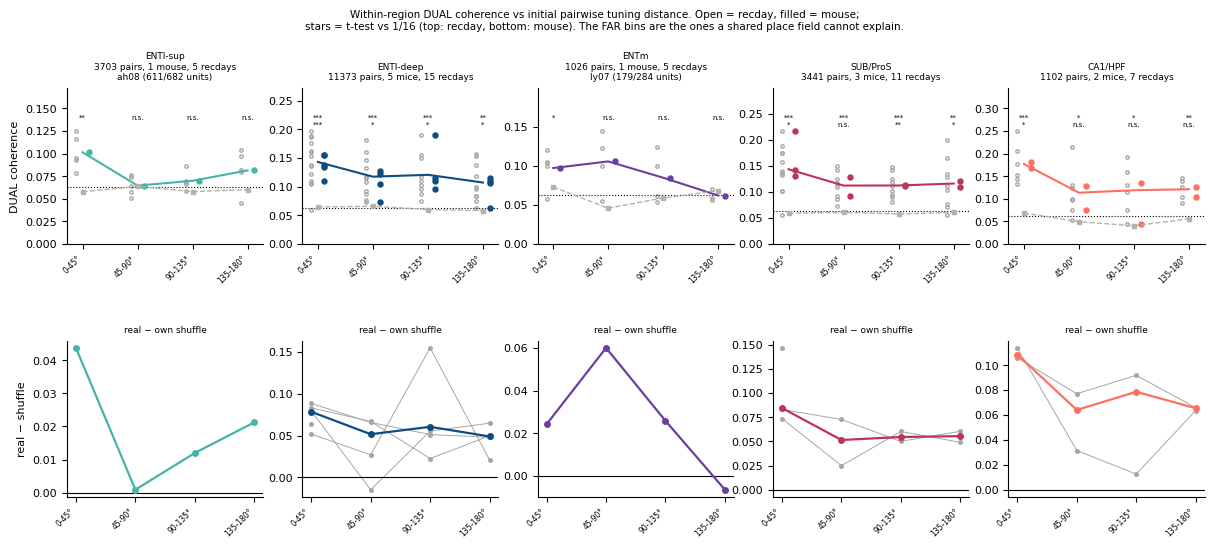

In [11]:
fig6r = wf.fig6_per_region(pairs, save_dir=FIG_DIR)

**Result.** The far-bin coherence is carried by the two regions with real multi-animal n:**ENTl-deep** (5 mice, 15 recdays) is significant in *every* bin including 135–180°, and**SUB/ProS** (3 mice, 11 recdays) likewise. CA1/HPF is recday-significant throughout butmouse-level n.s. beyond the first bin on 2 mice. **ENTm and ENTl-sup are single-mouse here**and do not hold up in the distal bins — consistent with them being ly07 and ah08 wearingregion labels, not with a regional difference.

### 3.2c Why an earlier prototype found nothing at distal distances`LEC_sploratory_analysis_with_glm_and_population.ipynb` (cells 341/347/350) ran this analysisand reported 90–135° p=0.992 and 135–180° p=0.978 against a flat 1/16 — both with *negative*t. Reproducing that structure here shows it is a **yardstick error, not a different result**.Neither the missing state-tuning gate nor the 3-task-triplet structure matters; the metricdoes.The direct metric is `Δ_ij(Y) − Δ_ij(X)` and the bin is `|Δ_ij(X)|` — **the pair's own angleis in both**, so its chance level is not 1/16. A pair-identity shuffle (keep `Δ_ij(X)`,compare against a random *other* pair's `Δ(Y)`, `Δ(Z)`) measures what chance actually is perbin. The ref-anchored metric is built from each neuron's own rotation, never conditions on`Δ_ij(X)`, and so keeps 1/16 — which is why the figures above use it.

Figure 7 plots the direct metric against **its own** chance, globally and per region. Thedotted line is the flat 1/16; the dashed line is what chance actually is. The own-chance line*falls* with distance (0.097 → 0.048) while 1/16 is flat — that gap is the whole discrepancy.Globally the direct metric is significant at **every** distance with **5/5 mice positive inall four bins**. Per region it runs out of power distally (region subsets have few pairs perrecday and the empirical null adds variance), which is the other reason the ref-anchoredmetric — fixed, valid 1/16, no per-bin null needed — is the one the claims rest on.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig7_direct_vs_own_chance.{png,pdf}
    0-45°: real 0.2081 own-chance 0.0967 ratio 2.15 | recday *** (24/24) | mouse *
   45-90°: real 0.0814 own-chance 0.0564 ratio 1.48 | recday *** (21/23) | mouse *
  90-135°: real 0.0627 own-chance 0.0493 ratio 1.28 | recday *** (22/24) | mouse *
 135-180°: real 0.0673 own-chance 0.0478 ratio 1.45 | recday *** (20/23) | mouse *


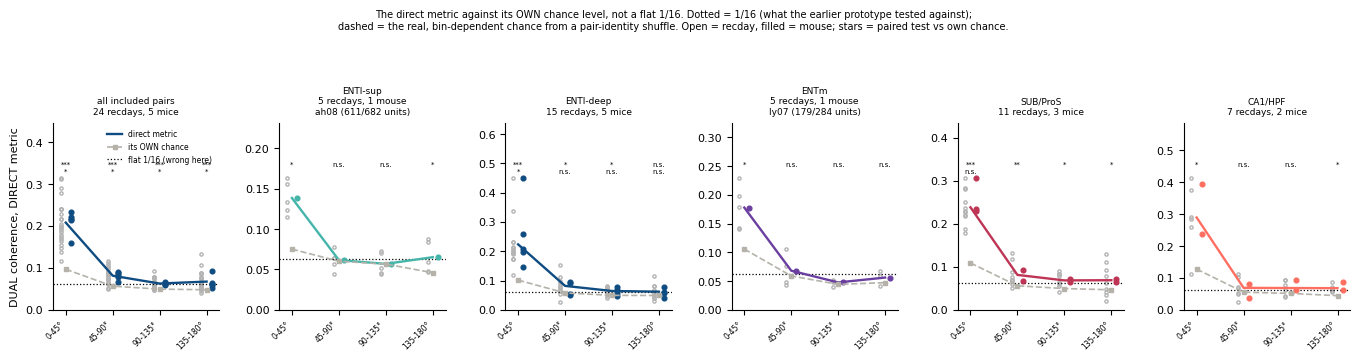

In [12]:
fig7, direct_df = wf.fig7_direct_vs_own_chance(results, unit_regions, save_dir=FIG_DIR)
g = direct_df[direct_df['group'] == 'ALL']
for lab in sorted(g['label'].unique(), key=lambda l: int(l.split('-')[0])):
    d = g[g['label'] == lab]
    pm = d.groupby('mouse')[['real', 'chance']].mean()
    print(f"{lab:>9}: real {d['real'].mean():.4f} own-chance {d['chance'].mean():.4f} "
          f"ratio {d['ratio'].mean():.2f} | recday {wf.test_vs_shuffle(d['real'], d['chance'])['stars']}"
          f" ({wf.test_vs_shuffle(d['real'], d['chance'])['n_positive']}/"
          f"{wf.test_vs_shuffle(d['real'], d['chance'])['n']}) | "
          f"mouse {wf.test_vs_shuffle(pm['real'], pm['chance'])['stars']}")

In [13]:
print(wf.pair_identity_null_by_distance(results).round(4).to_string(index=False))
print("\nMarginal |pair angle| within a task — the reason the chance level moves:")
import itertools
marg = []
for r in results.values():
    idx = r.get('included_idx', [])
    if len(idx) < 3:
        continue
    iu = np.triu_indices(len(idx), 1)
    marg.append(np.abs(asplit.pairwise_angles(r['tuning'][r['unique_sessions'][1]][idx])[iu]))
m = np.concatenate(marg)
h = np.histogram(m, bins=[0, 45, 90, 135, 180])[0]
h = h / h.sum()
for lab, v in zip(['0-45', '45-90', '90-135', '135-180'], h):
    print(f"  {lab:>9}: {v:.3f}   (uniform on a circle = 0.250)   "
          f"predicted chance = {wf.DUAL_CHANCE * (v / 0.25) ** 2:.4f}")

     bin  n_recdays  direct  direct_own_chance  direct_over_own_chance  ref_anchored  flat_chance
   0-45°         25  0.2269             0.0865                  2.6235        0.1308       0.0625
  45-90°         25  0.0829             0.0526                  1.5749        0.1163       0.0625
 90-135°         25  0.0606             0.0470                  1.2892        0.0972       0.0625
135-180°         25  0.0768             0.0576                  1.3331        0.0997       0.0625

Marginal |pair angle| within a task — the reason the chance level moves:


       0-45: 0.299   (uniform on a circle = 0.250)   predicted chance = 0.0896
      45-90: 0.239   (uniform on a circle = 0.250)   predicted chance = 0.0573
     90-135: 0.232   (uniform on a circle = 0.250)   predicted chance = 0.0537
    135-180: 0.230   (uniform on a circle = 0.250)   predicted chance = 0.0527


### 3.3 Figure 4 — coherence within each regionDensities use every pair: a density estimate is unbiased whatever n is, so nothing is gainedby discarding pairs for the *shape*. The equal-count matching W3 requires belongs to thescalar comparison in §3.4, where unequal n really would change the answer.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig4_within_region.{png,pdf}
    group  n_pairs  n_mice  real  shuffle   gap mice_positive               caveat
 ENTl-sup     3703       4 0.279    0.245 0.034           3/4 ah08 (611/682 units)
ENTl-deep    11373       5 0.345    0.252 0.093           5/5                     
     ENTm     1026       4 0.293    0.256 0.036           2/4 ly07 (179/284 units)
 SUB/ProS     3441       4 0.344    0.246 0.098           4/4                     
  CA1/HPF     1102       2 0.353    0.243 0.111           2/2                     


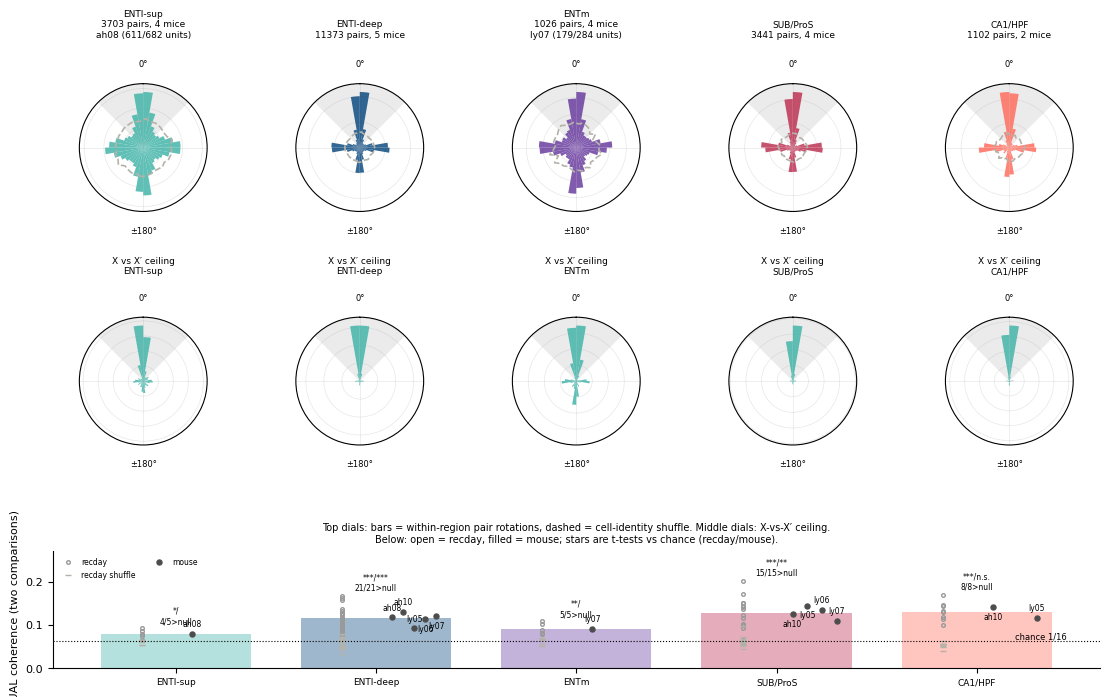

In [14]:
fig4 = wf.fig4_within_region(pairs, save_dir=FIG_DIR)
rows = []
for g in asplit.ANALYSIS_GROUPS:
    sub = pairs[(pairs['group_i'] == g) & (pairs['group_j'] == g)]
    if len(sub) < 200:
        continue
    by_mouse = [(m, wf.per_comparison_rate(s, 'rel') - wf.per_comparison_rate(s, 'relS'))
                for m, s in sub.groupby('mouse')]
    rows.append({'group': g, 'n_pairs': len(sub), 'n_mice': sub['mouse'].nunique(),
                 'real': wf.per_comparison_rate(sub, 'rel'),
                 'shuffle': wf.per_comparison_rate(sub, 'relS'),
                 'gap': wf.per_comparison_rate(sub, 'rel') - wf.per_comparison_rate(sub, 'relS'),
                 'mice_positive': f"{sum(v > 0 for _, v in by_mouse)}/{len(by_mouse)}",
                 'caveat': asplit.SINGLE_MOUSE_GROUPS.get(g, '')})
print(pd.DataFrame(rows).round(3).to_string(index=False))

### 3.4 Figure 5 — are coherent pairs same-region or cross-region?**This is the question the workstream exists for.** Two matchings are load-bearing:- **pair count**, because `n_pairs ~ n²` and a region with twice the neurons brings four  times the pairs; and- **initial tuning distance**, because §3.2 just showed coherence depends on it, and  same-region neurons plausibly have more similar tuning than cross-region ones. Unmatched,  the figure returns "same-region" for free and is measuring tuning similarity, not anatomy.The null shuffles region labels **within recday** (preserving each recday's composition andthe mouse↔region association, which is the confound) and **over neurons, not pairs** — apair's two labels are not independent draws.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig5_same_vs_cross.{png,pdf}
  observed_gap: 0.010414333980254323
  null_mean: -2.109247142280221e-05
  null_sd: 0.006297259010735451
  p_perm: 0.08782435129740519
  n_perm: 500
  n_mice: 4
  n_recdays: 19

within - cross, RECDAY level (n=19): mean +0.0101, 10/19 positive, t-test vs 0 p=0.042
within - cross, MOUSE  level (n=4): mean +0.0104, 3/4 positive, t-test vs 0 p=0.061

Per mouse:
       within_ENTl-deep  within_SUB/ProS   cross  within_pooled  null_within  null_cross
mouse                                                                                   
ah10             0.1298           0.1259  0.1318         0.1278       0.0613      0.0607
ly05             0.0794           0.1564  0.1009         0.1179       0.0551      0.0692
ly06             0.1164           0.1251  0.1047         0.1207       0.0600      0.0655
ly07             0.1200           0.1108  0.1029         0.1154       0.0601  

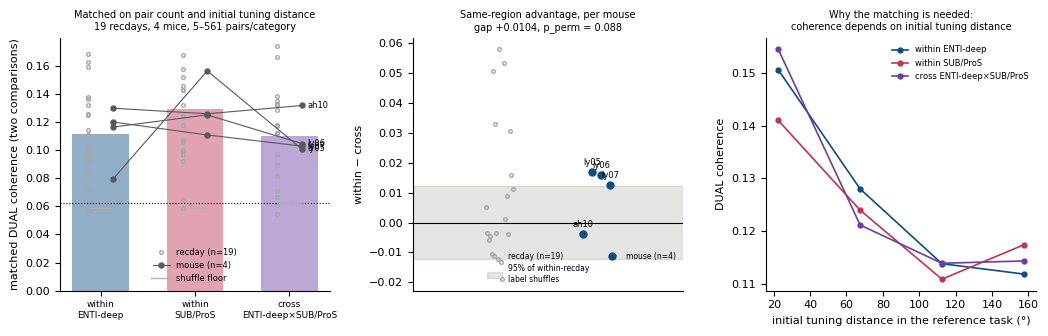

In [15]:
null5 = wf.matched_coherence_null(pairs, *asplit.PRIMARY_CONTRAST, n_perm=500)
fig5, per_rd_5 = wf.fig5_same_vs_cross(pairs, *asplit.PRIMARY_CONTRAST, null=null5,
                                       save_dir=FIG_DIR)
for k, v in null5.items():
    if k not in ('per_mouse', 'null_draws'):
        print(f'  {k}: {v}')

rd5 = null5['per_mouse']                      # one row per recday
pm5 = rd5.groupby('mouse').mean(numeric_only=True)
gap_rd = rd5['within_pooled'] - rd5['cross']
gap_ms = pm5['within_pooled'] - pm5['cross']
print(f"\nwithin - cross, RECDAY level (n={len(gap_rd)}): mean {gap_rd.mean():+.4f}, "
      f"{int((gap_rd > 0).sum())}/{len(gap_rd)} positive, "
      f"t-test vs 0 p={wf.test_vs_chance(gap_rd, 0)['p']:.3f}")
print(f"within - cross, MOUSE  level (n={len(gap_ms)}): mean {gap_ms.mean():+.4f}, "
      f"{int((gap_ms > 0).sum())}/{len(gap_ms)} positive, "
      f"t-test vs 0 p={wf.test_vs_chance(gap_ms, 0)['p']:.3f}")
print('\nPer mouse:')
print(pm5[[f'within_{asplit.PRIMARY_CONTRAST[0]}', f'within_{asplit.PRIMARY_CONTRAST[1]}',
           'cross', 'within_pooled', 'null_within', 'null_cross']].round(4).to_string())
print('\nwithin - cross, per mouse:', gap_ms.round(4).to_dict())

**Result — coherent remapping is not anatomical.**The same-region advantage is **+0.010 on a base of ~0.12**, against a within-recday labelshuffle of 0.000 ± 0.006, **p_perm = 0.09** over 19 recdays and 4 mice.It does not survive scrutiny at either level. At the recday level a t-test against zerogives p = 0.04, but **only 10 of 19 recdays are positive** — a coin flip, so that p iscarried by a few large days rather than a consistent effect. At the mouse level it isp = 0.06 with **3 of 4 mice positive**, and the one that is negative is **ah10**, whichcontributes by far the most data. The permutation null — the test that actually preserveseach recday's region composition — gives p = 0.09.Cross-region pairs are about as coherent as within-region pairs. Whatever holds thepopulation's relative task-space angles together operates **across** ENTl-deep and SUB/ProS,not within each separately.

### 3.5 Do the coherence modules recover the anatomy?A stronger form of the same question, and the one W3 flags as most likely to yield a newclaim. Rather than testing a contrast we chose, let the coherence structure define its ownmodules — agglomerative clustering on the incoherence matrix, *k* by maximum silhouette —and ask whether those modules recover the region labels.

In [16]:
cva = w3.cluster_vs_anatomy(results, unit_regions, n_perm=200)
print(cva.round(3).to_string(index=False))
print(f"\nmean ARI {cva['ari'].mean():.4f} vs null {cva['ari_null_mean'].mean():.4f} | "
      f"recdays at p<0.05: {int((cva['p_perm'] < 0.05).sum())}/{len(cva)} "
      f"(chance would be ~{0.05 * len(cva):.1f}) | {cva['mouse'].nunique()} mice")
print('per-mouse ARI:', cva.groupby('mouse')['ari'].mean().round(4).to_dict())

                recday mouse  n_neurons  n_clusters  silhouette  n_regions    ari    ami  ari_null_mean  ari_null_sd  p_perm
ah08_20250613_20250615  ah08         36          11       0.247          2  0.036  0.037          0.001        0.028   0.100
ah08_20250616_20250617  ah08         38          11       0.414          2 -0.014 -0.057         -0.001        0.011   0.955
ah08_20250618_20250619  ah08         65          12       0.243          2 -0.010  0.022          0.001        0.012   0.821
ah08_20250620_20250623  ah08         41          11       0.292          2  0.023  0.048          0.000        0.020   0.154
ah08_20250624_20250625  ah08         70          12       0.394          2 -0.017 -0.000          0.001        0.013   0.950
ah10_20250613_20250615  ah10        116          12       0.211          6  0.024  0.014         -0.001        0.022   0.134
ah10_20250616_20250617  ah10        126          12       0.219          5 -0.002 -0.004          0.003        0.027   0.557


**Result — a clean null.** ARI 0.000 against a null of 0.000, with 1 of 25 recdays reachingp<0.05 (chance would be 1.25). The clusters are real — silhouettes 0.16–0.56, and theEl-Gaby port already showed they beat a state-offset shuffle — but **they do not follow theanatomy**. Coherent remapping is organised by something other than region.

## §4 — CCGP: the population form of the same questionA decoder trained on some tasks and tested on a held-out one generalises only if stateidentity is abstract across tasks. This can find structure distributed across cells that isinvisible one neuron at a time, so it is a genuine independent check on §2.Run twice: **matched n = 20** so regions can be compared, and **full n** as a within-regionexistence claim against that region's own null — never as a cross-region comparison, sincefull-n ENTl-deep at 80 units beating full-n SUB/ProS at 41 is expected from n alone.

  wrote /ceph/behrens/adam_harris/Taskspace_abstraction_lEC/data/figures/anatomy_split/fig8_ccgp_by_region.{png,pdf}
--- ccgp_matched: accuracy vs its OWN role-permutation null, paired per recday ---
    ENTl-sup: acc 0.443  null 0.500  within-task ceiling 0.695  |  4/4 recdays BELOW null, p=6.2e-02  |  1 mice, mean n=20
   ENTl-deep: acc 0.451  null 0.500  within-task ceiling 0.750  |  18/20 recdays BELOW null, p=2.0e-04  |  5 mice, mean n=20
        ENTm: acc 0.465  null 0.498  within-task ceiling 0.699  |  4/5 recdays BELOW null, p=6.2e-02  |  1 mice, mean n=20
    SUB/ProS: acc 0.450  null 0.499  within-task ceiling 0.749  |  14/15 recdays BELOW null, p=5.8e-04  |  3 mice, mean n=20
     CA1/HPF: acc 0.445  null 0.501  within-task ceiling 0.763  |  7/9 recdays BELOW null, p=4.9e-02  |  2 mice, mean n=20

--- ccgp_full: accuracy vs its OWN role-permutation null, paired per recday ---
    ENTl-sup: acc 0.443  null 0.503  within-task ceiling 0.771  |  6/6 recdays BELOW null, p=1.6e-02

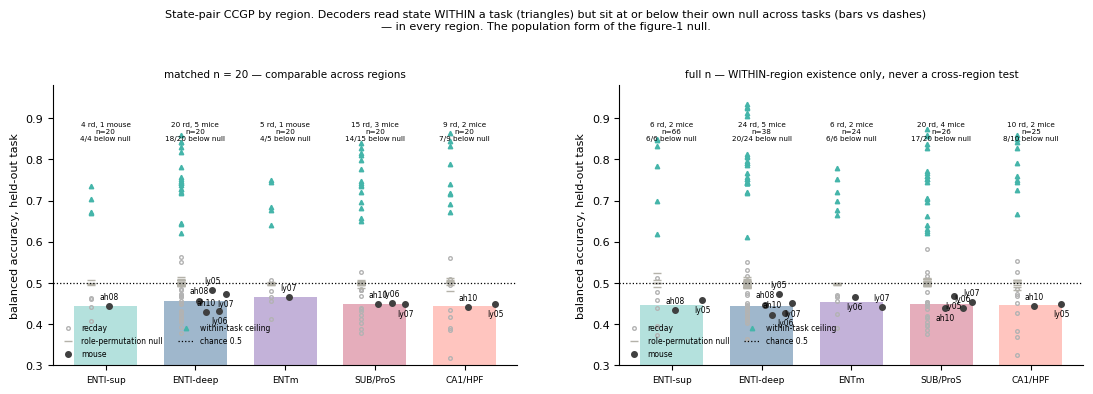

In [17]:
fig8 = wf.fig8_ccgp_by_region(extras.get('ccgp_matched'), extras.get('ccgp_full'),
                              save_dir=FIG_DIR)
for key in ('ccgp_matched', 'ccgp_full'):
    if key not in extras:
        continue
    rd, pm = wf.ccgp_levels(extras[key])
    print(f'--- {key}: accuracy vs its OWN role-permutation null, paired per recday ---')
    for g in asplit.ANALYSIS_GROUPS:
        r, m = rd[rd['group'] == g], pm[pm['group'] == g]
        if not len(r):
            continue
        t = wf.test_vs_shuffle(r['null_mean'], r['acc'])   # null > acc = fails to generalise
        print(f"  {g:>10}: acc {r['acc'].mean():.3f}  null {r['null_mean'].mean():.3f}  "
              f"within-task ceiling {r['ceiling'].mean():.3f}  |  "
              f"{t['n_positive']}/{t['n']} recdays BELOW null, p={t['p']:.1e}  |  "
              f"{m['mouse'].nunique()} mice, mean n={r['n_units'].mean():.0f}")
    print()

In [18]:
if 'ccgp_matched' in extras:
    for key, title in (('ccgp_matched', 'matched n=20 — comparable across regions'),
                       ('ccgp_full', 'full n — WITHIN-region existence only')):
        df = extras.get(key)
        if df is None or not len(df):
            print(f'--- CCGP, {title}: not computed yet ---\n')
            continue
        per_mouse = (df.groupby(['group', 'mouse'])[['acc', 'null_mean', 'ceiling', 'n_units']]
                     .mean().reset_index())
        summ = (per_mouse.groupby('group')
                .agg(n_mice=('mouse', 'nunique'), n_units=('n_units', 'mean'),
                     acc=('acc', 'mean'), null=('null_mean', 'mean'),
                     ceiling=('ceiling', 'mean')).reindex(asplit.ANALYSIS_GROUPS).dropna())
        summ['acc_minus_null'] = summ['acc'] - summ['null']
        print(f'--- CCGP, {title} ---')
        print(summ.round(3).to_string())
        print()
else:
    print('run `python w3_remapping.py --extras` first')

--- CCGP, matched n=20 — comparable across regions ---
           n_mice  n_units    acc   null  ceiling  acc_minus_null
group                                                            
ENTl-sup        1     20.0  0.443  0.500    0.695          -0.057
ENTl-deep       5     20.0  0.455  0.499    0.755          -0.044
ENTm            1     20.0  0.465  0.498    0.699          -0.033
SUB/ProS        3     20.0  0.450  0.499    0.749          -0.050
CA1/HPF         2     20.0  0.445  0.501    0.770          -0.056

--- CCGP, full n — WITHIN-region existence only ---
           n_mice  n_units    acc   null  ceiling  acc_minus_null
group                                                            
ENTl-sup        2    66.00  0.447  0.503    0.743          -0.056
ENTl-deep       5    38.02  0.444  0.498    0.791          -0.054
ENTm            2    23.90  0.454  0.496    0.695          -0.042
SUB/ProS        4    26.35  0.450  0.501    0.743          -0.051
CA1/HPF         2    24.90  0.446 

## §5 — Robustness: does the reference task matter?Reference anchoring has one specific failure mode — every neuron's rotation is measuredagainst one task, so an unrepresentative reference corrupts the whole recday at once. Thecheck is to rotate which task plays the anchor. This is cheap because the cache holds thetuning curves and the per-task pairwise angle matrices; only the comparisons against theanchor are redone.

In [19]:
rob = w3.reference_robustness(results, unit_regions)
print(rob.round(4).to_string(index=False))
print(f"\nsingle-neuron gap across reference choices: "
      f"{rob['single_gap'].min():+.4f} to {rob['single_gap'].max():+.4f}")
print(f"pairwise gap across reference choices:      "
      f"{rob['pair_gap'].min():+.4f} to {rob['pair_gap'].max():+.4f}")

 reference_rank  n_recdays  single_real  single_shuffle  pair_real  pair_shuffle  pair_direct  single_gap  pair_gap
              0         25       0.2369          0.2446     0.3373        0.2496       0.3093     -0.0077    0.0877
              1         25       0.2508          0.2501     0.3225        0.2502       0.3051      0.0007    0.0723
              2         25       0.2442          0.2421     0.3163        0.2514       0.3033      0.0021    0.0649
              3         25       0.2653          0.2424     0.3274        0.2501       0.3061      0.0229    0.0772
              4         21       0.2418          0.2467     0.3477        0.2506       0.3153     -0.0049    0.0971
              5         16       0.2380          0.2579     0.3201        0.2500       0.2988     -0.0199    0.0701

single-neuron gap across reference choices: -0.0199 to +0.0229
pairwise gap across reference choices:      +0.0649 to +0.0971


## §6 — Synthetic controlsRepo practice: every new analysis is gated on synthetics pushed through the **real**pipeline — they enter as `Neuron_raw` and `Trial_times` and are binned, warped, smoothed,gated and rotated by the production code, not handed a ready-made tuning curve. This hascaught seven plausible-looking design errors across the project, including control 7 below,which was a live bug in this notebook's own code path.

In [20]:
import w3_synthetics
assert w3_synthetics.run_all(verbose=True) == 0, 'synthetic controls FAILED — do not trust the figures above'

[PASS] 1 rotation recovery
       all rotations recovered exactly (xcorr + peak)


[PASS] 2 pair coherence: rigid vs independent
       DUAL: rigid 1.000/1.000, independent 0.0682/0.0682 (ref-anchored/direct; analytic dual chance 0.0625)


[PASS] 3 ordinal-state generalises, place does not
       gate passed 16/16; generalising: state 1.00, place 0.00


[PASS] 4 anatomy join: two rigid modules
       within 1.00, cross 0.00, label-shuffled gap -0.05 (276 pairs)


[PASS] 5 cell-identity shuffle preserves h=4
       1.00 quantised to multiples of 90; per-comparison 0.26 (chance 0.25); all-5-comparison generalising 0.000


[PASS] 6 one-pass tuning build equivalence
       one-pass build matches rr.build_session_tuning exactly


[PASS] 7 ragged task counts across recdays
       ragged recdays scored independently: 20250101 5c gen=1.00 coh=1.00, 20250103 4c gen=1.00 coh=1.00



7/7 controls passed


## Summary**1. State cells do not generalise.** 12 generalising cells in 2851 unit-recordings; thecross-task angle distribution sits on its own cell-identity shuffle at both the recday(p = 0.34) and mouse (p = 0.31) level and in every region, while the X-vs-X′ ceiling is 0.81. The measurement works; the constancy is not there. This agreeswith the production GLM (`task_state` last of 16) and with CCGP (0.426 vs a 0.500 null).**2. Remapping is coherent.** On the dual (two-comparison, chance 1/16) criterion, pairs holdtheir relative task-space angle above the shuffle floor in **24/25 recdays and 5/5 mice**(recday p = 1×10⁻⁹, mouse p = 0.002), on both the reference-anchored and the reference-freemetric, and matching El-Gaby's strict first-two-comparisons parity. It **survivesrestriction to pairs that started ≥90° apart** (22/23 recdays, mouse p = 0.001), so it isnot co-tuned or co-place-tuned pairs.**3. The coherence is not anatomical.** Same-region pairs beat cross-region pairs by +0.010,but only 10/19 recdays and 3/4 mice are positive, the label-shuffle null gives p = 0.09, andthe largest mouse runs the other way. Coherence modules recover the region labels at exactlychance (ARI 0.000, 1/25 recdays at p<0.05). ENTl-deep and SUB/ProS rotate **together**, notas independent modules.### What this does not license- **Nothing here is about ENTl-sup or ENTm as regions.** They are ah08 and ly07 wearing  region labels.- **The gate is rate-dependent**, and the pass rate varies more between mice (33–84% within  ENTl-deep alone) than between regions. The per-region *null* is robust to rate matching;  a per-region *difference* would not have been.- **The negative in §3.4 is a bounded negative, not proof of no effect.** With 4 mice and a  null SD of 0.006, effects smaller than about 0.012 are not resolvable.- **The dual X-vs-X′ ceiling exists in only 9 recdays / 3 mice.** It needs two exact task  repeats, and 8 recdays have none — the data has 4–7 unique tasks per recday, not the  nominal 6+2.- **W3 §5, the leg-duration / time-cell confound, was deliberately not run.** A  fixed-latency time cell passes the gate and then fails generalisation by construction. It  cannot manufacture the §3 coherence result, but it is one contributor to the §2 null that  has not been separated out.